<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Logistic Regression Practice

---

# Titanic
On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing over 1,500 of its 2,224 passengers and crew. Survival wasn't random — factors like class, sex, and age all played a role in who made it into a lifeboat.

You will be predicting `Survived`: whether a passenger survived (1) or did not (0), using their ticket and demographic information.

# Imports

In [26]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, precision_score, f1_score

### 1. Load the data

Read in the `titanic.csv` data.

In [6]:
# TODO:
df= pd.read_csv("./data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Drop columns that won’t help the model

> `PassengerId` is just a row ID, `Name` and `Ticket` are high-cardinality free text, and `Cabin` is missing for the vast majority of passengers.

In [7]:
# TODO:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 3. Handle missing values

> Check for missing values. `Age` and `Embarked` both have null values, fill them in (median for `Age` and the most common value for `Embarked`).

In [9]:
# TODO:
df.isnull().sum()

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Modeling

### 4. Set up your target and features, and split into training and testing sets

Set `Survived` as your target, `y`. Everything else remaining is your feature matrix, `X`.

In [10]:
# TODO:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((712, 7), (179, 7))

### 5. Establish a baseline

What accuracy would you get by always predicting the majority class? This is the number your model needs to beat.

In [11]:
# TODO:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

baseline_acc = dummy.score(X_test, y_test)
baseline_acc

0.6145251396648045

### 6. Build a `Pipeline` with a `ColumnTransformer`

> Use a `ColumnTransformer` to scale your numeric features and encode your categorical features. Then chain it into a `Pipeline`.

In [12]:
# TODO:
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']

preprocessing = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), num_cols),
    ('onehotencoder', OneHotEncoder(drop='first'), cat_cols)
])

pipe = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', LogisticRegression())
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, def

### 7. Fit your pipeline and evaluate train vs. test accuracy

Is there a meaningful gap between train and test performance? Is this model better than the null model?

In [13]:
# TODO:
pipe.fit(X_train, y_train)

train_acc = pipe.score(X_train, y_train)
test_acc = pipe.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 0.8104
Test accuracy: 0.8045


### 8. Confusion matrix

> Generate a confusion matrix for your model's predictions on the test set. Which type of mistake is your model making more (predicting survival for someone who didn't, or the reverse?)

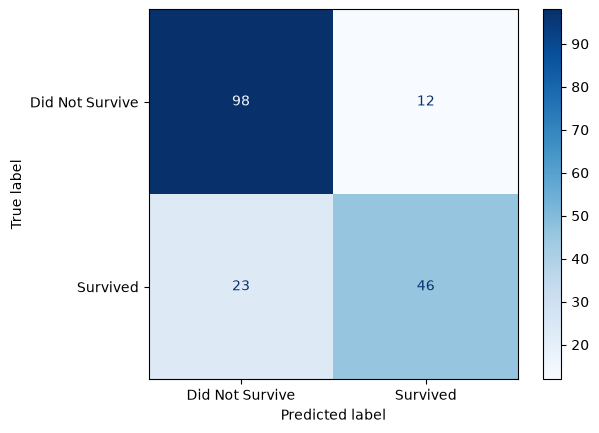

In [14]:
# TODO:
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(cmap='Blues')
plt.show()

### 9. Classification report

> Print a classification report (precision, recall, f1-score) for the test set.

In [16]:
# TODO:
# Accuracy
print(f'accuracy :{accuracy_score(y_test,y_pred)}')

# Recall / Sensitivity / True Positive Rate (TPR)
print(f'recall TPR :{recall_score(y_test,y_pred)}')


# Precision
print(f'precision :{precision_score(y_test,y_pred)}')


# Specificity / True Negative Rate (TNR) is not defined in scikit-learn
specificity=recall_score(y_test,y_pred,pos_label=0)
print(f'specificity TNR:{specificity}')


# F1 score
print(f'f1 score :{f1_score(y_test,y_pred)}')

accuracy :0.8044692737430168
recall TPR :0.6666666666666666
precision :0.7931034482758621
specificity TNR:0.8909090909090909
f1 score :0.7244094488188977


# Interpretation & Predictions

### 10. Pull out your feature names and coefficients

> Your `ColumnTransformer` renames and reorders your columns when it transforms `X`, the numeric columns keep their original names, but the one-hot encoded categorical columns get new names like `Sex_male`. Before you can interpret any coefficient, you need to know which coefficient belongs to which feature.
>
> 1. Get the one-hot encoded feature names out of your fitted `ColumnTransformer` using:
>
>    `.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)`.
> 
> 2. Combine these with your numeric column names, **in the same order your `ColumnTransformer` outputs them** (e.g. numeric columns first, then categorical).
> 
> 3. Pair these feature names with your fitted model's `.coef_[0]` values in a `pandas.Series` (feature names as the index), so you can look up any coefficient by name.

In [17]:
# TODO:
cat_feature_names = pipe.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)

all_feature_names = num_cols + list(cat_feature_names)

coefficients = pd.Series(pipe.named_steps['model'].coef_[0], index=all_feature_names)
coefficients

Age          -0.466638
SibSp        -0.260281
Parch        -0.069135
Fare          0.175186
Pclass_2     -0.731616
Pclass_3     -1.917942
Sex_male     -2.530449
Embarked_Q    0.222367
Embarked_S   -0.436645
dtype: float64

### 11. Interpret one coefficient

> Pick one feature and interpret its coefficient. Convert it from log-odds into an odds ratio (`np.exp(coef)`), and explain in a sentence what it does to the odds of survival.

In [18]:
# TODO:
coef_sex_male = coefficients['Sex_male']
odds_ratio = np.exp(coef_sex_male)
odds_ratio

np.float64(0.07962322465528768)

>The coefficient for Sex_male converts to an odds ratio of 0.0796. This means that if all the other features are constant,
>male passengers had 0.0796 times higher odds of surviving compared to the baseline group.

### 12. Generate predictions and predicted probabilities

> Use your model to generate `.predict()` and `.predict_proba()` on the test set. Pick one test observation and explain, in a sentence, what its predicted probability means.

In [21]:
# TODO:
y_pred =pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)
picked=y_pred[4]
prob_died = y_pred_proba[4][0]
prob_serv = y_pred_proba[4][1]
print(f"The observation is 4, the prediction: {picked} \nPredicted Probability of Dying - 0: {prob_died} \nPredicted Probability of Surviving - 1: {prob_serv}")

The observation is 4, the prediction: 1 
Predicted Probability of Dying - 0: 0.33154633783898624 
Predicted Probability of Surviving - 1: 0.6684536621610138


>For test observation index 4, the model estimates a 66.85% probability that this passenger survived, which exceeds the 50% decision threshold, leading the model to assign a final prediction of 1 (Survived).

### 12. Try a different threshold

> `.predict()` uses a default threshold of 0.5 on `.predict_proba()` to decide the class. Try lowering it and recompute the confusion matrix and classification report at this new threshold. What trade-off do you see between precision and recall?

In [23]:
# TODO:
y_probs = pipe.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= 0.3)
cm2=confusion_matrix(y_test, y_pred_custom)

print(cm2)
# Accuracy
print(f'Accuracy: {accuracy_score(y_test, y_pred_custom)}')

# Recall / Sensitivity / True Positive Rate (TPR)
print(f'Recall(TPR): {recall_score(y_test, y_pred_custom)}')

# Precision
print(f'Precision: {precision_score(y_test, y_pred_custom)}')

# Specificity / True Negative Rate (TNR)
specificity = recall_score(y_test, y_pred_custom, pos_label=0)
print(f'Specificity(TNR): {specificity}')

#F1 score
print(f'F1 score: {f1_score(y_test, y_pred_custom)}')

[[83 27]
 [14 55]]
Accuracy: 0.770949720670391
Recall(TPR): 0.7971014492753623
Precision: 0.6707317073170732
Specificity(TNR): 0.7545454545454545
F1 score: 0.7284768211920529


### 13. Write a function to print classification metrics with explanations

> Write a function `print_classification_metrics(y_true, y_pred)` that calculates **accuracy**, **recall/sensitivity**, **precision**, **specificity**, and **F1 score**, and prints each metric alongside a clear explanation. Then call your function on your model's test set predictions.
>
> Use the confusion matrix layout below as your reference for which cells (`TP`, `TN`, `FP`, `FN`) each metric is built from.

**Accuracy** — Overall, how often is the classifier correct?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Accuracy} = \frac{TP + TN}{Total}$$

**Recall / Sensitivity / True Positive Rate (TPR)** — Among all passengers who actually survived, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Recall} = \frac{TP}{TP + FN}$$

**Precision** — Among all passengers predicted to survive, what proportion actually did?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Precision} = \frac{TP}{TP + FP}$$

**Specificity / True Negative Rate (TNR)** — Among all passengers who did not actually survive, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center">TP</td>
</tr>
</table>

$$\textbf{Specificity} = \frac{TN}{TN + FP}$$

**$F_1$ score** — The balance between precision and recall.

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


In [27]:
# TODO:
def print_classification_metrics(y_true, y_pred):
    # Extract confusion matrix values: TP, TN, FP, FN
    cm = metrics.confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics using explicit formulas
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    specificity = tn / (tn + fp)
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Print metrics with explanations
    print(f"Accuracy: {accuracy}")
    print("Explanation: Proportion of all predictions that were correct (TP + TN) / Total.\n")

    print(f"Recall / Sensitivity: {recall}")
    print("Explanation: Proportion of actual positive cases correctly identified TP / (TP + FN).\n")

    print(f"Precision: {precision}")
    print("Explanation: Proportion of positive predictions that were actually correct TP / (TP + FP).\n")

    print(f"Specificity: {specificity}")
    print("Explanation: Proportion of actual negative cases correctly identified TN / (TN + FP).\n")

    print(f"F1 Score: {f1}")
    print("Explanation: Harmonic mean of precision and recall balancing false positives and false negatives.")

# Call the function on test set predictions
y_pred = pipe.predict(X_test)
print_classification_metrics(y_test, y_pred)

Accuracy: 0.8044692737430168
Explanation: Proportion of all predictions that were correct (TP + TN) / Total.

Recall / Sensitivity: 0.6666666666666666
Explanation: Proportion of actual positive cases correctly identified TP / (TP + FN).

Precision: 0.7931034482758621
Explanation: Proportion of positive predictions that were actually correct TP / (TP + FP).

Specificity: 0.8909090909090909
Explanation: Proportion of actual negative cases correctly identified TN / (TN + FP).

F1 Score: 0.7244094488188977
Explanation: Harmonic mean of precision and recall balancing false positives and false negatives.
